In [1]:
from pynq.overlays.base import BaseOverlay

ol = BaseOverlay("base.bit")

from pynq.ps import Clocks

In [2]:
clock_frequency = Clocks.cpu_mhz

print(f'CPU frequency:   {clock_frequency:.6f}MHz')

CPU frequency:   650.000000MHz


In [3]:
import time
import ctypes
from fibModified import recur_fibo

_libInC = ctypes.CDLL('./libcycletime.so')

In [ ]:
maxFibonacciTerms=30

xAxis = [] #terms
timeDiffInUsecArr=[]
counterDerivedTimeInUsecArr=[]


def elapsedTimeCalculator(fibSeriesTerm):
    _libInC.init_counters(1, 0)

    beforeTime = time.time()
    beforeCounter=_libInC.get_cyclecount()

    recur_fibo(fibSeriesTerm)#isoltae to 1 and run taskset
    
    afterTime = time.time()
    afterCounter=_libInC.get_cyclecount()

    timeDiff=afterTime-beforeTime #in units of second
    counterDiff=afterCounter-beforeCounter #in units of cycles

    timeDiffInUsec = timeDiff*1000000
    counterDerivedTimeInUsec=counterDiff/clock_frequency
    #because clockspeed is on Mhz i.e. cycles*pow(10,6) per sec i.e. 650*pow(10,6) cycles per sec or 650 cycles per usec

    return timeDiffInUsec,counterDerivedTimeInUsec

for fibSeriesTerm in range(maxFibonacciTerms):

    timeDiffInUsec,counterDerivedTimeInUsec = elapsedTimeCalculator(fibSeriesTerm)
    '''
    _libInC.init_counters(1, 0)

    beforeTime = time.time()
    beforeCounter=_libInC.get_cyclecount()

    recur_fibo(fibSeriesTerm)

    afterTime = time.time()
    afterCounter=_libInC.get_cyclecount()

    timeDiff=afterTime-beforeTime #in units of second
    counterDiff=afterCounter-beforeCounter #in units of cycles

    timeDiffInUsec = timeDiff*1000000
    counterDerivedTimeInUsec=counterDiff/clock_frequency

    '''

    xAxis.append(fibSeriesTerm)
    timeDiffInUsecArr.append(timeDiffInUsec)
    counterDerivedTimeInUsecArr.append(counterDerivedTimeInUsec)

    #print("iteration {}".format(fibSeriesTerm))
    #print("time diff in usec:{}".format(timeDiffInUsec))
    #print("counter diff:{}-{}={}".format(afterCounter,beforeCounter,counterDiff)) 
    #print("using counterDiff and Freq, elapsed time is usec:{}".format(counterDerivedTimeInUsec))

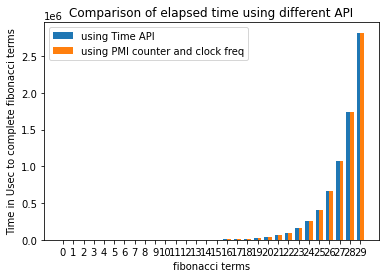

In [53]:
#used a sample reference code from internet for plotting of side by side bar

import matplotlib.pyplot as plt
import numpy as np

category_names=xAxis
values1=timeDiffInUsecArr
values2=counterDerivedTimeInUsecArr

# Position of bars on the x-axis
x = np.arange(len(category_names))

# Width of each bar
width = 0.35

# Create the bars
plt.bar(x - width/2, values1, width, label='using Time API')
plt.bar(x + width/2, values2, width, label='using PMI counter and clock freq')

# Add labels and title
plt.xlabel('fibonacci terms')
plt.ylabel('Time in Usec to complete fibonacci terms')
plt.title('Comparison of elapsed time using different API')
plt.xticks(x, category_names)
plt.legend()

# Display the plot
plt.show()

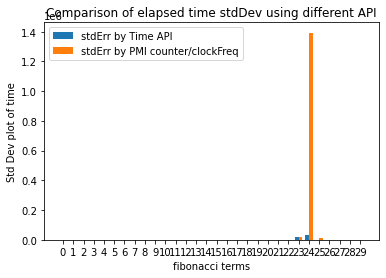

In [61]:
import math

timeDiffStdDevArr = []
counterDiffStdDevArr = []
xAxis = []

#for fibSeriesTerm in range(2,maxFibonacciTerms,5):
for fibSeriesTerm in range(maxFibonacciTerms):

    xAxis.append(fibSeriesTerm)
    timeDiffInUsecArr = []
    counterDerivedTimeInUsecArr = []

    numofIterations=3

    #calculating mean
    for i in range(numofIterations): # run every term 3 times
        timeDiffInUsec,counterDerivedTimeInUsec = elapsedTimeCalculator(fibSeriesTerm)
        #xAxis.append(fibSeriesTerm)
        timeDiffInUsecArr.append(timeDiffInUsec)
        counterDerivedTimeInUsecArr.append(counterDerivedTimeInUsec)

    timeDiffInUsecMean = sum(timeDiffInUsecArr) / len(timeDiffInUsecArr)
    counterDerivedTimeInUsecMean = sum(counterDerivedTimeInUsecArr) / len(counterDerivedTimeInUsecArr)

    # calculating stdDev
    timeDiffSqrd=0
    counterDiffSqrd=0

    for i in range(numofIterations):
        timeDiffSqrd += pow((timeDiffInUsecArr[i]-timeDiffInUsecMean),2)
        counterDiffSqrd += pow((counterDerivedTimeInUsecArr[i]-counterDerivedTimeInUsecMean),2)
    
    timeDiffError = math.sqrt(timeDiffSqrd/len(timeDiffInUsecArr))
    counterDiffError = math.sqrt(counterDiffSqrd/len(counterDerivedTimeInUsecArr))
    
    timeDiffStdDevArr.append(timeDiffError)
    counterDiffStdDevArr.append(counterDiffError)
    #print("timeError {}".format(timeDiffError))
    #print("counterError {}".format(counterDiffError))
#drawing side by side barchart plot

#plotting the side by side bar chart
category_names=xAxis
values1=timeDiffStdDevArr
values2=counterDiffStdDevArr

# Position of bars on the x-axis
x = np.arange(len(category_names))

# Width of each bar
width = 0.35

# Create the bars
plt.bar(x - width/2, values1, width, label='stdErr by Time API')
plt.bar(x + width/2, values2, width, label='stdErr by PMI counter/clockFreq')

# Add labels and title
plt.xlabel('fibonacci terms')
plt.ylabel('Std Dev plot of time')
plt.title('Comparison of elapsed time stdDev using different API')
plt.xticks(x, category_names)
plt.legend()

# Display the plot
plt.show()